Original Data:
    Name  Age  Marks  Attendance
0   Aman   20   85.0        90.0
1   Riya   21   78.0        85.0
2  Rahul   19    NaN        80.0
3  Sneha   22   88.0         NaN
4  Karan   20   76.0        88.0

Missing Values Before:
Name          0
Age           0
Marks         2
Attendance    2
dtype: int64

Missing Values After Filling:
Name          0
Age           0
Marks         0
Attendance    0
dtype: int64


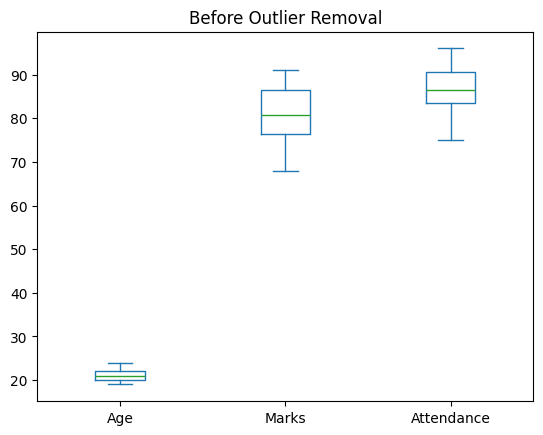


Data After Outlier Removal:
      Name  Age      Marks  Attendance
0     Aman   20  85.000000   90.000000
1     Riya   21  78.000000   85.000000
2    Rahul   19  80.846154   80.000000
3    Sneha   22  88.000000   86.461538
4    Karan   20  76.000000   88.000000
5     Neha   21  82.000000   91.000000
6    Arjun   23  90.000000   95.000000
7    Priya   20  75.000000   84.000000
8    Rohit   22  80.846154   87.000000
9   Simran   21  89.000000   92.000000
10   Vikas   24  72.000000   78.000000
11  Anjali   23  91.000000   96.000000
12  Deepak   22  68.000000   75.000000
13   Pooja   21  80.000000   86.461538
14  Manish   20  77.000000   83.000000


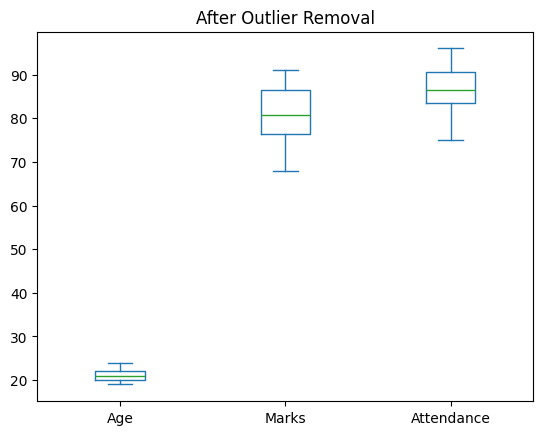

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data4.csv")

print("Original Data:")
print(df.head())

print("\nMissing Values Before:")
print(df.isnull().sum())

df_filled = df.copy()
df_filled.fillna(df_filled.mean(numeric_only=True), inplace=True)

print("\nMissing Values After Filling:")
print(df_filled.isnull().sum())

df_filled.select_dtypes(include='number').plot(kind='box')
plt.title("Before Outlier Removal")
plt.show()

numeric_df_filled = df_filled.select_dtypes(include='number')

Q1 = numeric_df_filled.quantile(0.25)
Q3 = numeric_df_filled.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((numeric_df_filled < (Q1 - 1.5 * IQR)) | (numeric_df_filled > (Q3 + 1.5 * IQR))).any(axis=1)

df_no_outliers = df_filled[~outlier_mask]

print("\nData After Outlier Removal:")
print(df_no_outliers)

df_no_outliers.select_dtypes(include='number').plot(kind='box')
plt.title("After Outlier Removal")
plt.show()